In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset , DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Playdata\miniconda3\envs\myenv\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Playdata\miniconda3\envs\myenv\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Playdata\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Playdata\AppData\Roaming\Python\Python310\site-packages\traitlets\config\application.py", line 1075, in lau

In [2]:
X_xor = torch.tensor([[0.0, 0.0],  # 0   0  0
                      [0.0, 1.0],  # 1   0  1
                      [1.0, 0.0],  # 1   0  1
                      [1.0, 1.0]]) # 1   1  0

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]])

In [3]:
class XORnet(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden = nn.Linear(2,4)
    self.output = nn.Linear(4,1)
  def forward(self,x):
    x = torch.relu(self.hidden(x))
    x = torch.sigmoid(self.output(x))
    return x
model = XORnet()
model.parameters()

<generator object Module.parameters at 0x000001813AE70890>

In [4]:
class XORNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden = nn.Linear(2,4)
    self.output = nn.Linear(4,1)
  def forward(self, x):
    x = torch.relu(self.hidden(x))
    x = torch.sigmoid(self.output(x))
    return x

model =  XORNet()
for p in model.parameters():
  print(f'학습가능한 파라메터수 : {p.numel()}')
  print(f'가중치 및 바이어스 값: {p}')

학습가능한 파라메터수 : 8
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.1045, -0.3301],
        [ 0.1802, -0.3258],
        [-0.0829, -0.2872],
        [ 0.4691, -0.5582]], requires_grad=True)
학습가능한 파라메터수 : 4
가중치 및 바이어스 값: Parameter containing:
tensor([-0.3260, -0.1997, -0.4252,  0.0667], requires_grad=True)
학습가능한 파라메터수 : 4
가중치 및 바이어스 값: Parameter containing:
tensor([[-0.4938,  0.4516, -0.4247,  0.3860]], requires_grad=True)
학습가능한 파라메터수 : 1
가중치 및 바이어스 값: Parameter containing:
tensor([0.0832], requires_grad=True)


In [5]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters() , lr=1e-2)

In [6]:
epochs = 1000
loss_history = []
for epoch in range(epochs):
  optimizer.zero_grad()
  predict = model(X_xor)
  loss = criterion(predict,y_xor)
  loss.backward()
  optimizer.step()
  loss_history.append(loss.item())
  if (epoch+1) % 100 == 0 :
    print(f'epoch : {epoch+1} , loss : {loss.item()}')

epoch : 100 , loss : 0.544783890247345
epoch : 200 , loss : 0.4926280975341797
epoch : 300 , loss : 0.48342275619506836
epoch : 400 , loss : 0.4805908501148224
epoch : 500 , loss : 0.4794631004333496
epoch : 600 , loss : 0.47883158922195435
epoch : 700 , loss : 0.47847452759742737
epoch : 800 , loss : 0.47830286622047424
epoch : 900 , loss : 0.4780099391937256
epoch : 1000 , loss : 0.4778714179992676


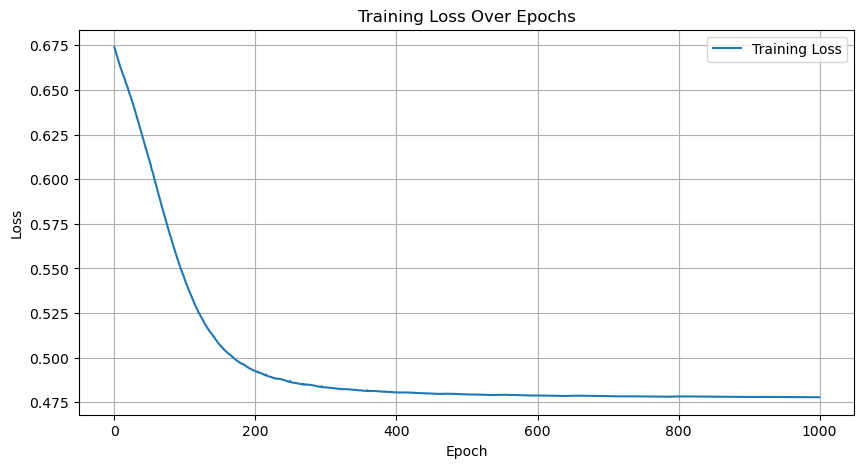

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
model.eval() # 모델을 평가 모드로 전환
with torch.no_grad():
    final_predictions = model(X_xor)
    # 예측값을 이진 분류 결과로 변환 (0.5를 기준으로)
    predicted_classes = (final_predictions >= 0.5).float()

print("Input (X_xor):\n", X_xor)
print("Target (y_xor):\n", y_xor)
print("Model Predictions (raw):\n", final_predictions)
print("Model Predictions (binary):\n", predicted_classes)
model.train() # 모델을 다시 학습 모드로 전환 (선택 사항)

Input (X_xor):
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Target (y_xor):
 tensor([[0.],
        [1.],
        [1.],
        [0.]])
Model Predictions (raw):
 tensor([[0.3340],
        [0.3340],
        [0.9981],
        [0.3340]])
Model Predictions (binary):
 tensor([[0.],
        [0.],
        [1.],
        [0.]])


XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)

In [9]:
accuracy = (predicted_classes == y_xor).float().mean()
print(f"Model Accuracy: {accuracy.item()*100:.2f}%")

Model Accuracy: 75.00%


In [13]:
import torch
from sklearn.datasets import load_iris
X = torch.tensor(load_iris().data, dtype=torch.float32)
y = torch.tensor(load_iris().target, dtype=torch.long)

In [14]:
train_dataset = TensorDataset(X,y)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
for data in train_loader :
  print(data)
  break

[tensor([[5.8000, 2.7000, 4.1000, 1.0000],
        [4.9000, 2.5000, 4.5000, 1.7000],
        [5.7000, 2.8000, 4.5000, 1.3000],
        [6.4000, 2.9000, 4.3000, 1.3000],
        [5.6000, 2.8000, 4.9000, 2.0000],
        [5.9000, 3.2000, 4.8000, 1.8000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [6.7000, 3.3000, 5.7000, 2.1000],
        [6.4000, 3.1000, 5.5000, 1.8000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.6000, 3.0000, 4.1000, 1.3000],
        [6.2000, 3.4000, 5.4000, 2.3000],
        [5.2000, 4.1000, 1.5000, 0.1000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [6.3000, 3.3000, 4.7000, 1.6000],
        [5.6000, 2.9000, 3.6000, 1.3000]]), tensor([1, 2, 1, 1, 2, 1, 0, 2, 2, 0, 1, 2, 0, 0, 1, 1])]
